# Setup Environment and Dataset

In [1]:
# 1. Install Visualization & Analytical Dependencies
!pip install ultralytics matplotlib pandas seaborn opencv-python pillow pyyaml -q
print("Dependencies installed successfully.")

import os
import zipfile
import yaml
from google.colab import drive

# 2. mount Google Drive
drive.mount('/content/drive')

# 3. extract dataset to local temporary storage
zip_path = '/content/drive/MyDrive/Car Exterior Damage Detection.v3i.yolov8.zip'
extract_path = '/content/dataset'

if not os.path.exists(extract_path):
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

# 4. configure data.yaml paths
yaml_path = f"{extract_path}/data.yaml"
with open(yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

data_config['train'] = f"{extract_path}/train/images"
data_config['val'] = f"{extract_path}/valid/images"
data_config['test'] = f"{extract_path}/test/images"

with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.0/66.0 kB 6.8 MB/s eta 0:00:00
Dependencies installed successfully.
Mounted at /content/drive
Extracting dataset...


# Exploratory Data Analysis (EDA) & Annotation Preprocessing

     EXPLORATORY DATA ANALYSIS REPORT
Damage Class  Instance Count  Percentage (%)
       crack            1317           10.87
        dent            1577           13.02
        rust            3647           30.11
     scratch            5570           45.99


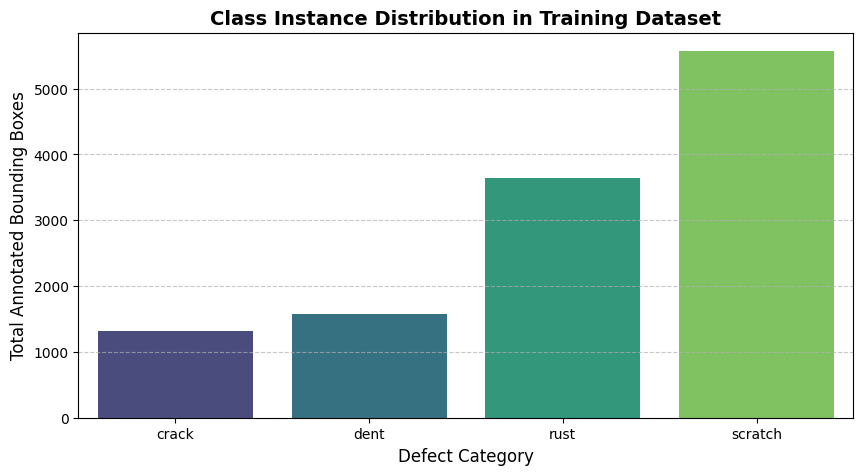

In [2]:
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extract class names from YAML
class_names = data_config['names']
class_counts = {name: 0 for name in class_names}

# Parse training label text files
label_files = glob.glob(os.path.join(extract_path, 'train/labels/*.txt'))

for label_file in label_files:
    with open(label_file, 'r') as f:
        for line in f.readlines():
            parts = line.strip().split()
            if parts:
                class_id = int(parts[0])
                class_name = class_names[class_id]
                class_counts[class_name] += 1

# Display Dataset Statistics Table
df_stats = pd.DataFrame(list(class_counts.items()), columns=['Damage Class', 'Instance Count'])
df_stats['Percentage (%)'] = round((df_stats['Instance Count'] / df_stats['Instance Count'].sum()) * 100, 2)

print("="*40)
print("     EXPLORATORY DATA ANALYSIS REPORT")
print("="*40)
print(df_stats.to_string(index=False))
print("="*40)

# Plot Class Distribution Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=df_stats, x='Damage Class', y='Instance Count', hue='Damage Class', legend=False, palette='viridis')
plt.title('Class Instance Distribution in Training Dataset', fontsize=14, fontweight='bold')
plt.xlabel('Defect Category', fontsize=12)
plt.ylabel('Total Annotated Bounding Boxes', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(extract_path, 'eda_class_distribution.png'), bbox_inches='tight')
plt.show()

# Initial Training (YOLOv8s, 50 Epochs, 800px)

In [ ]:
# 1. Load pre-trained YOLOv8 small model
model = YOLO('yolov8s.pt')

# 2. Train model and save output into damage_model_yolov8s_800px_finetuned
train_results = model.train(
    data=yaml_path,
    epochs=50,
    imgsz=800,
    project='/content',
    name='damage_model_yolov8s_800px_finetuned',
    exist_ok=True,
    device=0
)

print("Phase 1 training completed. Best weights saved at:")
print("/content/damage_model_yolov8s_800px_finetuned/weights/best.pt")

# Clean Label Files (Reclaims the 28 Ignored Images)

In [3]:
import glob

# Paths to clean
label_paths = glob.glob('/content/dataset/*/labels/*.txt')
cleaned_count = 0

for file_path in label_paths:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    clean_lines = []
    for line in lines:
        parts = line.strip().split()
        # Keep only standard bounding box lines (class_id + 4 spatial values)
        if len(parts) == 5:
            clean_lines.append(line)
        elif len(parts) > 5:
            # If line contains segmentation points, keep only first 5 values
            clean_lines.append(" ".join(parts[:5]) + "\n")
            cleaned_count += 1

    with open(file_path, 'w') as f:
        f.writelines(clean_lines)

print(f"Cleaned {cleaned_count} mixed label lines across dataset.")

Cleaned 2587 mixed label lines across dataset.


# Re-Extract the Clean Dataset

In [4]:
import shutil
import zipfile
import os

# Clear modified dataset folder and re-extract fresh copy
if os.path.exists('/content/dataset'):
    shutil.rmtree('/content/dataset')

zip_path = '/content/drive/MyDrive/Car Exterior Damage Detection.v3i.yolov8.zip'
extract_path = '/content/dataset'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset re-extracted cleanly.")

Dataset re-extracted cleanly.


# Convert Polygons to True YOLO Bounding Boxes

In [5]:
import glob

label_paths = glob.glob('/content/dataset/*/labels/*.txt')
converted_count = 0

for file_path in label_paths:
    with open(file_path, 'r') as f:
        lines = f.readlines()

    clean_lines = []
    for line in lines:
        parts = line.strip().split()
        if not parts:
            continue

        if len(parts) == 5:
            # Keep valid 5-column bounding box lines
            clean_lines.append(line.strip() + "\n")
        elif len(parts) > 5:
            # Convert polygon coordinates to true bounding box coordinates
            class_id = parts[0]
            coords = [float(x) for x in parts[1:]]
            xs = coords[0::2]
            ys = coords[1::2]

            min_x, max_x = min(xs), max(xs)
            min_y, max_y = min(ys), max(ys)

            x_center = (min_x + max_x) / 2.0
            y_center = (min_y + max_y) / 2.0
            width = max_x - min_x
            height = max_y - min_y

            clean_lines.append(f"{class_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n")
            converted_count += 1

    with open(file_path, 'w') as f:
        f.writelines(clean_lines)

print(f"Correctly converted {converted_count} polygon instances into true bounding boxes.")

Correctly converted 2587 polygon instances into true bounding boxes.


# Execute the 800px Fine-Tuning Training

In [ ]:
from ultralytics import YOLO

# 1. Load the custom 50-epoch weights from Google Drive
previous_weights = '/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned/weights/best.pt'
model = YOLO(previous_weights)

# 2. Execute 50 fine-tuning epochs at 800px resolution
results = model.train(
    data=yaml_path,
    epochs=50,                  # Train for 50 additional fine-tuning epochs
    imgsz=800,                  # Higher image resolution for small defects
    batch=8,                    # Reduced batch size to fit GPU VRAM
    workers=4,
    amp=True,                   # FP16 mixed precision for speed
    mixup=0.15,                 # Image blending augmentation
    mosaic=1.0,                 # Scale variance augmentation
    project='/content/drive/MyDrive/YOLOv8_Final_Run',
    name='damage_model_yolov8s_800px_finetuned',
    exist_ok=True
)

Ultralytics 8.4.129 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned/weights/best.pt, mome

# Model Accuracy & Test Evaluation

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO

save_folder = '/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned'
csv_path = f"{save_folder}/results.csv"

# Parse training performance logs
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

final_epoch = df.iloc[-1]
print("="*50)
print("      YOLOv8s ACCURACY EVALUATION SUMMARY")
print("="*50)
print(f"Epochs Completed: {int(final_epoch['epoch'])}")
print(f"Precision (P):     {final_epoch['metrics/precision(B)']:.4f}")
print(f"Recall (R):        {final_epoch['metrics/recall(B)']:.4f}")
print(f"mAP@50:            {final_epoch['metrics/mAP50(B)']:.4f}  <-- Target Core Metric")
print("="*50)

# Evaluate best weight model against the test set
best_model_path = f"{save_folder}/weights/best.pt"
best_model = YOLO(best_model_path)
val_results = best_model.val(data=yaml_path, split='test')

print("\nPer-Class Accuracy Breakdown (mAP50):")
for i, class_name in enumerate(val_results.names.values()):
    class_map = val_results.box.maps[i]
    print(f" - {class_name}: {class_map:.4f}")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
      YOLOv8s ACCURACY EVALUATION SUMMARY
Epochs Completed: 50
Precision (P):     0.4373
Recall (R):        0.3040
mAP@50:            0.2681  <-- Target Core Metric
Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 895.2±304.9 MB/s, size: 53.2 KB)
test: Scanning /content/dataset/test/labels... 192 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 192/192 2.3Kit/s 0.1s
test: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 

# Model Evaluation & Graph Generation

Ultralytics 8.4.130 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
test: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1826.5±520.4 MB/s, size: 46.2 KB)
test: Scanning /content/dataset/test/labels.cache... 192 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 192/192 57.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.6it/s 7.3s
                   all        192        573       0.56      0.323      0.309      0.137
                 crack         50         64      0.477      0.391       0.32      0.187
                  dent         34         45      0.749      0.422      0.452      0.168
                  rust         51        204      0.537       0.27      0.251     0.0978
               scratch         75        260      0.477      0.208      0.213     0.0941
Speed: 10.3ms preprocess, 14.0ms inference, 0

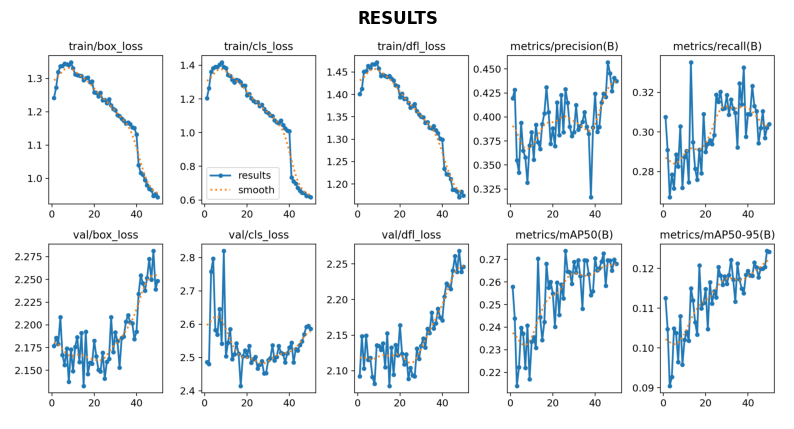

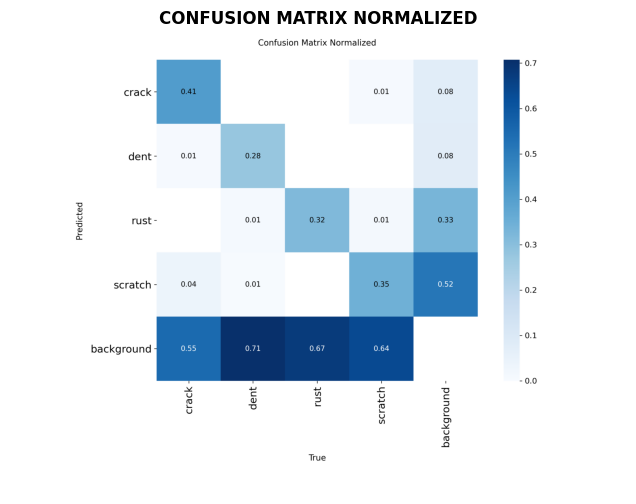

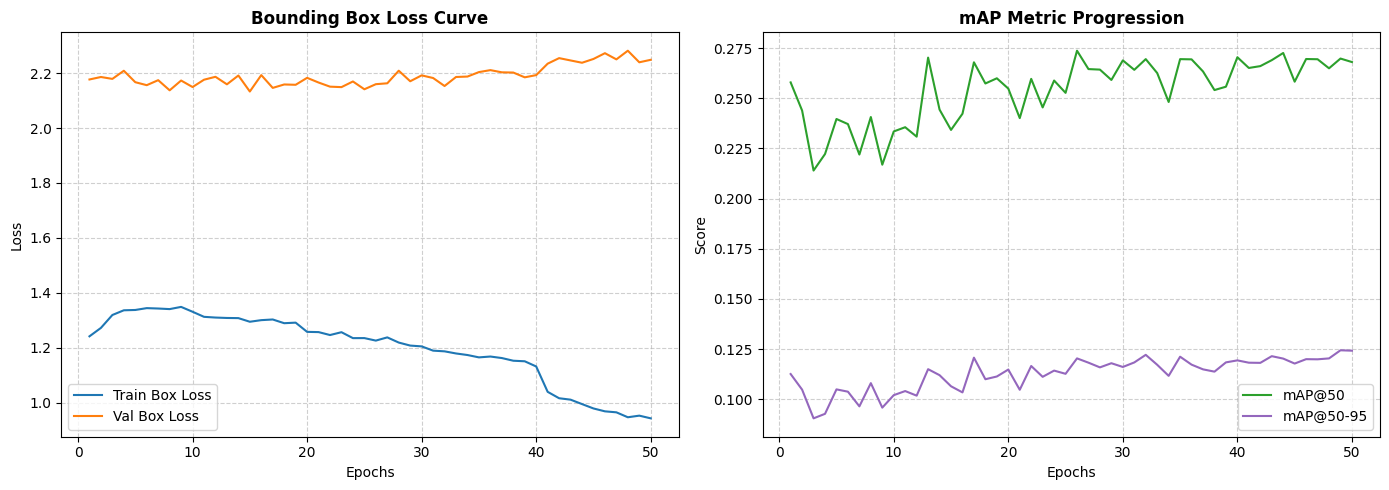

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

# 1. Load the fine-tuned best weights
best_weights_path = '/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned/weights/best.pt'
final_model = YOLO(best_weights_path)

# 2. Evaluate on the test dataset split
metrics = final_model.val(data=yaml_path, imgsz=800, split='test')

# 3. Display summary metrics
print("=" * 45)
print("          FINAL MODEL TEST EVALUATION")
print("=" * 45)
print(f"Mean Average Precision (mAP50):    {metrics.box.map50:.4f}")
print(f"Mean Average Precision (mAP50-95): {metrics.box.map:.4f}")
print(f"Overall Precision:                 {metrics.box.mp:.4f}")
print(f"Overall Recall:                    {metrics.box.mr:.4f}")
print("=" * 45)

# 4. Render Ultralytics generated performance plots
run_dir = '/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned'
target_plots = ['results.png', 'confusion_matrix_normalized.png', 'F1_curve.png', 'PR_curve.png']

for plot_name in target_plots:
    plot_path = os.path.join(run_dir, plot_name)
    if os.path.exists(plot_path):
        plt.figure(figsize=(10, 6))
        img = Image.open(plot_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(plot_name.replace('.png', '').replace('_', ' ').upper(), fontsize=12, fontweight='bold')
        plt.show()

# 5. Plot Loss & mAP progression over epochs from results.csv
csv_path = os.path.join(run_dir, 'results.csv')
if os.path.exists(csv_path):
    df_results = pd.read_csv(csv_path)
    df_results.columns = [c.strip() for c in df_results.columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss graph
    axes[0].plot(df_results['epoch'], df_results['train/box_loss'], label='Train Box Loss', color='#1f77b4')
    axes[0].plot(df_results['epoch'], df_results['val/box_loss'], label='Val Box Loss', color='#ff7f0e')
    axes[0].set_title('Bounding Box Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epochs')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, linestyle='--', alpha=0.6)

    # mAP graph
    axes[1].plot(df_results['epoch'], df_results['metrics/mAP50(B)'], label='mAP@50', color='#2ca02c')
    axes[1].plot(df_results['epoch'], df_results['metrics/mAP50-95(B)'], label='mAP@50-95', color='#9467bd')
    axes[1].set_title('mAP Metric Progression', fontweight='bold')
    axes[1].set_xlabel('Epochs')
    axes[1].set_ylabel('Score')
    axes[1].legend()
    axes[1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# Download the New best.pt

In [ ]:
from google.colab import files
files.download('/content/drive/MyDrive/YOLOv8_Final_Run/damage_model_yolov8s_800px_finetuned/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>